# 🌀 颱風路徑類比預測 — Coastline RRF（最新算法，自包含版）

本 notebook **不依賴專案套件**（無 `import data_pipiline`），所有用到的演算法程式碼皆已內聯，
可單獨交給他人執行。**唯一外部需求**：

- Python 套件：`numpy`、`pandas`、`matplotlib`
- 資料檔：`typhoons_overview.json`（路徑見下方 `DATA_PATH`）

演算法：**`coastline_rrf`**（LOO 準確率 82.3%）——以海岸線範圍內**絕對位置相似度**為主（0.80），
用 RRF 融合 **KNN**（0.20）與**可選降水**排名做三訊號投票。

> 👉 **`BUFFER_KM`（海岸線外擴公里數）= 計算範圍，是核心輸入參數**。


## 0. 匯入（僅標準科學套件）


In [9]:
import json
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

## 1. 參數設定（使用者輸入）

`BUFFER_KM` 為計算範圍（海岸線外擴公里數）；`DATA_PATH` 指向資料檔。


In [10]:
# ====== 使用者可調整的輸入參數 ======
BUFFER_KM       = 500     # ★ 計算範圍：台灣海岸線向外擴張的公里數（核心輸入，50~2000）
K               = 5       # 取最相似的前 K 條颱風
USE_RAINFALL    = False   # 是否納入事件降水相似度（可選訊號）
RAINFALL_REGION = 'tn'    # 降水地區：tn=臺南, kh=高雄

# RRF 融合權重（絕對位置占極高比重）與參數
W_COASTLINE = 0.80
W_KNN       = 0.20
W_RAINFALL  = 0.08        # USE_RAINFALL=True 時生效
RRF_K       = 60
POOL        = K * 12      # 候選池大小

# 資料檔路徑（請依實際位置調整）
DATA_PATH = Path('data/typhoon/preprocessed/typhoons_overview.json')
if not DATA_PATH.exists():
    DATA_PATH = Path.cwd().parent / 'data' / 'typhoon' / 'preprocessed' / 'typhoons_overview.json'
assert DATA_PATH.exists(), f'找不到資料檔：{DATA_PATH}'
print('資料檔:', DATA_PATH, '| 計算範圍: 海岸線外擴', BUFFER_KM, 'km')

資料檔: c:\Users\yuhan\workplace\yu-codes\flux-data-engine\data\typhoon\preprocessed\typhoons_overview.json | 計算範圍: 海岸線外擴 500 km


## 2. 台灣海岸線與外擴緩衝區（幾何）

內聯：台灣本島輪廓、經緯度↔本地 km 平面投影、到海岸線距離、範圍裁切遮罩、外擴緩衝多邊形。


In [11]:
# 投影參考點（台灣中心）與每度公里數
REF_LAT, REF_LON = 23.7, 121.0
KM_PER_DEG_LAT, KM_PER_DEG_LON = 110.57, 111.32
_COS_REF = np.cos(np.radians(REF_LAT))

# 台灣本島海岸線輪廓（順時針，(lon, lat)）
TAIWAN_OUTLINE_LONLAT = [
    (121.53, 25.30), (121.69, 25.16), (122.00, 25.01), (121.86, 24.85),
    (121.85, 24.60), (121.75, 24.13), (121.55, 23.78), (121.50, 23.40),
    (121.40, 23.10), (121.20, 22.80), (121.00, 22.45), (120.90, 22.00),
    (120.85, 21.90), (120.74, 21.93), (120.55, 22.30), (120.30, 22.55),
    (120.15, 22.95), (120.10, 23.30), (120.13, 23.70), (120.50, 24.30),
    (120.78, 24.65), (121.00, 25.00), (121.25, 25.13), (121.40, 25.28),
]

def lonlat_to_km(lon, lat):
    lon = np.asarray(lon, float); lat = np.asarray(lat, float)
    return (lon - REF_LON) * KM_PER_DEG_LON * _COS_REF, (lat - REF_LAT) * KM_PER_DEG_LAT

def km_to_lonlat(x, y):
    x = np.asarray(x, float); y = np.asarray(y, float)
    return REF_LON + x / (KM_PER_DEG_LON * _COS_REF), REF_LAT + y / KM_PER_DEG_LAT

def _outline_km():
    pts = np.array(TAIWAN_OUTLINE_LONLAT, float)
    x, y = lonlat_to_km(pts[:, 0], pts[:, 1])
    return np.column_stack([x, y])

def _points_in_polygon(px, py, poly):
    n = len(poly); inside = np.zeros(len(px), bool); j = n - 1
    for i in range(n):
        xi, yi = poly[i]; xj, yj = poly[j]
        cond = ((yi > py) != (yj > py)) & (px < (xj - xi) * (py - yi) / (yj - yi + 1e-12) + xi)
        inside ^= cond; j = i
    return inside

def _points_to_polyline_min(px, py, poly):
    A = poly; B = np.roll(poly, -1, axis=0); AB = B - A
    denom = np.maximum(np.einsum('md,md->m', AB, AB), 1e-12)
    P = np.column_stack([px, py]); AP = P[:, None, :] - A[None, :, :]
    t = np.clip(np.einsum('nmd,md->nm', AP, AB) / denom, 0.0, 1.0)
    proj = A[None, :, :] + t[:, :, None] * AB[None, :, :]
    d = np.hypot(proj[:, :, 0] - px[:, None], proj[:, :, 1] - py[:, None])
    return d.min(axis=1)

def distances_to_coast_km(lons, lats):
    poly = _outline_km(); x, y = lonlat_to_km(lons, lats)
    x = np.atleast_1d(x).astype(float); y = np.atleast_1d(y).astype(float)
    d = _points_to_polyline_min(x, y, poly)
    d[_points_in_polygon(x, y, poly)] = 0.0
    return d

def clip_mask(lons, lats, buffer_km, min_points=2):
    lons = np.asarray(lons, float); lats = np.asarray(lats, float)
    d = distances_to_coast_km(lons, lats); mask = d <= buffer_km
    if mask.sum() < min_points:
        idx = np.argsort(d)[: max(min_points, len(d) // 5)]
        mask = np.zeros(len(d), bool); mask[idx] = True
    return mask

def _convex_hull(points):
    pts = np.array(sorted(map(tuple, points)))
    def cross(o, a, b): return (a[0]-o[0])*(b[1]-o[1]) - (a[1]-o[1])*(b[0]-o[0])
    lower = []
    for p in pts:
        while len(lower) >= 2 and cross(lower[-2], lower[-1], p) <= 0: lower.pop()
        lower.append(p)
    upper = []
    for p in reversed(pts):
        while len(upper) >= 2 and cross(upper[-2], upper[-1], p) <= 0: upper.pop()
        upper.append(p)
    return np.array(lower[:-1] + upper[:-1])

def buffer_polygon(buffer_km, arc_steps=6):
    hull = _convex_hull(_outline_km()); n = len(hull)
    normals = np.zeros((n, 2))
    for i in range(n):
        a = hull[i]; b = hull[(i + 1) % n]; ex, ey = b[0]-a[0], b[1]-a[1]
        ln = np.hypot(ex, ey) + 1e-12; normals[i] = (ey/ln, -ex/ln)
    out = []
    for i in range(n):
        a = hull[i]; ni = normals[i]; nip = normals[(i-1) % n]
        a0 = np.arctan2(nip[1], nip[0]); a1 = np.arctan2(ni[1], ni[0])
        if a1 < a0: a1 += 2*np.pi
        steps = max(1, int(np.ceil((a1-a0)/(np.pi/2/arc_steps))))
        for s in range(steps+1):
            ang = a0 + (a1-a0)*s/steps
            out.append((a[0]+buffer_km*np.cos(ang), a[1]+buffer_km*np.sin(ang)))
        b = hull[(i+1) % n]; out.append((b[0]+buffer_km*ni[0], b[1]+buffer_km*ni[1]))
    arr = np.array(out); lon, lat = km_to_lonlat(arr[:, 0], arr[:, 1])
    return list(zip(lon, lat))   # [(lon, lat), ...]

print('海岸線幾何就緒；500km 緩衝多邊形點數 =', len(buffer_polygon(500)))

海岸線幾何就緒；500km 緩衝多邊形點數 = 58


## 3. 載入資料

讀取 `typhoons_overview.json`，保留有路徑分類且軌跡點 ≥2 的颱風（對齊 207 筆評估池）。


In [12]:
_RAIN_NA = ('', '---', 'nan', 'none', 'na', 'n/a')
import re
def _parse_rain(v):
    if v is None: return None
    if isinstance(v, (int, float)): return None if (isinstance(v, float) and np.isnan(v)) else float(v)
    s = str(v).strip()
    if s.lower() in _RAIN_NA: return None
    m = re.search(r'-?\d+(\.\d+)?', s); return float(m.group()) if m else None

with open(DATA_PATH, encoding='utf-8') as f:
    raw = json.load(f)
typhoons = raw['typhoons'] if isinstance(raw, dict) else raw

records = []   # 每筆: dict(id, year, name_zh, name_en, category, landfall, rain, track DataFrame)
for t in typhoons:
    cat = str(t.get('taiwan_track_category', '') or '').strip()
    pts = (t.get('path') or {}).get('position_intensity') or []
    if not cat or len(pts) < 2:
        continue
    tdf = pd.DataFrame(pts)
    if 'timestamp_utc' in tdf.columns:
        tdf['timestamp_utc'] = pd.to_datetime(tdf['timestamp_utc'], errors='coerce', utc=True)
    records.append({
        'id': t['typhoon_id'], 'year': int(t['year']),
        'name_zh': t.get('name_zh', ''), 'name_en': t.get('name_en', ''),
        'category': cat, 'landfall': t.get('landfall_location'),
        'rain': {'tn': _parse_rain(t.get('event_rain_tn')), 'kh': _parse_rain(t.get('event_rain_kh'))},
        'track': tdf,
    })
label = {r['id']: r['category'] for r in records}
print('已載入', len(records), '筆颱風')

已載入 207 筆颱風


## 4. 特徵擷取（在計算範圍內）

**先把路徑裁切到海岸線外擴 `BUFFER_KM` 範圍內**，再計算 11 維摘要特徵（供 KNN）。


In [13]:
TAIWAN_LAT, TAIWAN_LON, EARTH_R = 23.7, 121.0, 6371.0
NORMAL_THETA = np.radians(60.0)

def haversine(lat1, lon1, lat2, lon2):
    lat1, lon1, lat2, lon2 = map(np.radians, [lat1, lon1, lat2, lon2])
    a = np.sin((lat2-lat1)/2)**2 + np.cos(lat1)*np.cos(lat2)*np.sin((lon2-lon1)/2)**2
    return EARTH_R * 2 * np.arcsin(np.sqrt(a))

def haversine_vec(lats, lons, rlat=TAIWAN_LAT, rlon=TAIWAN_LON):
    lat1 = np.radians(lats); lon1 = np.radians(lons); lat2 = np.radians(rlat); lon2 = np.radians(rlon)
    a = np.sin((lat2-lat1)/2)**2 + np.cos(lat1)*np.cos(lat2)*np.sin((lon2-lon1)/2)**2
    return EARTH_R * 2 * np.arcsin(np.sqrt(a))

def extract_features(track, buffer_km, landfall=None):
    track = track.copy()
    keep = clip_mask(track['longitude'].values.astype(float),
                     track['latitude'].values.astype(float), buffer_km)
    track = track[keep].reset_index(drop=True)
    lats = track['latitude'].values.astype(float); lons = track['longitude'].values.astype(float)
    r = haversine_vec(lats, lons)
    dy = lats - TAIWAN_LAT; dx = (lons - TAIWAN_LON) * np.cos(np.radians(lats))
    theta = np.arctan2(dy, dx)
    winds = track['wind_kt'].fillna(0).values.astype(float) if 'wind_kt' in track else np.zeros(len(lats))
    pres = track['pressure_mb'].fillna(1013).values.astype(float) if 'pressure_mb' in track else np.full(len(lats), 1013.0)
    min_dist = float(np.min(r))
    mean_ang = float(np.arctan2(np.mean(np.sin(theta)), np.mean(np.cos(theta))))
    max_wind = float(np.max(winds)) if len(winds) else 0.0
    # 接近速度（裁切段內）
    if len(lats) >= 2:
        td = sum(haversine(lats[i-1], lons[i-1], lats[i], lons[i]) for i in range(1, len(lats)))
        hrs = None
        if 'timestamp_utc' in track and pd.notna(track['timestamp_utc'].iloc[0]):
            tt = pd.to_datetime(track['timestamp_utc'])
            dh = (tt.iloc[-1]-tt.iloc[0]).total_seconds()/3600
            hrs = dh if dh > 0 else None
        approach = td/hrs if hrs else td/max((len(lats)-1)*3, 1)
    else:
        approach = 0.0
    valid_p = pres[pres < 1013]; min_pres = float(np.min(valid_p)) if len(valid_p) else 1013.0
    # 增強率（前半段斜率）
    half = max(2, len(winds)//2); fh = winds[:half]
    intens = float(np.polyfit(np.arange(len(fh)), fh, 1)[0]) if len(fh) >= 2 else 0.0
    safe_r = np.maximum(r, 1.0); wdir = np.maximum(0, np.cos(theta - NORMAL_THETA))
    rain_proxy = float(np.mean(winds * (0.5 + 0.5*wdir) / safe_r)) if len(winds) else 0.0
    is_lf = landfall is not None and str(landfall).strip() not in ('', '---', 'nan', 'None')
    birth_lon = float(lons[0]); birth_lat = float(lats[0])
    return np.array([min_dist, mean_ang, max_wind, max_wind, approach, min_pres,
                     intens, rain_proxy, float(is_lf), birth_lon, birth_lat], float)

print('特徵擷取函式就緒（11 維）')

特徵擷取函式就緒（11 維）


## 5. 相似度元件：KNN / Coastline / RRF 融合

- **KNN**：標準化加權特徵的歐式距離排名
- **Coastline**：範圍內路徑的對稱平均最近點（Chamfer）距離排名 —— 絕對位置
- **RRF**：以名次融合三訊號（Coastline 主導 + KNN + 可選降水）


In [14]:
SCORE_TAU_KM = 150.0
FEATURE_WEIGHTS = np.array([3.0, 2.0, 0.5, 0.5, 0.5, 0.5, 0.5, 0.5, 2.5, 0.5, 0.5])

# ---- Chamfer（km 平面） ----
def _pt_to_polyline(p, line):
    if len(line) == 1: return float(np.hypot(*(p - line[0])))
    a = line[:-1]; b = line[1:]; ab = b - a; ap = p - a
    denom = np.einsum('ij,ij->i', ab, ab)
    t = np.where(denom > 1e-12, np.einsum('ij,ij->i', ap, ab) / np.maximum(denom, 1e-12), 0.0)
    t = np.clip(t, 0, 1); proj = a + t[:, None] * ab
    return float(np.min(np.hypot(proj[:, 0]-p[0], proj[:, 1]-p[1])))

def chamfer_km(q, c):
    if len(q) == 0 or len(c) == 0: return float('inf')
    d1 = np.mean([_pt_to_polyline(p, c) for p in q])
    d2 = np.mean([_pt_to_polyline(p, q) for p in c])
    return 0.5 * (d1 + d2)

def path_offset_km(lons_a, lats_a, lons_b, lats_b, buffer_km):
    '''兩條路徑在範圍內的平均偏離 (km) — 顯示用絕對指標（必 > 0）。'''
    ma = clip_mask(lons_a, lats_a, buffer_km); mb = clip_mask(lons_b, lats_b, buffer_km)
    xa, ya = lonlat_to_km(lons_a, lats_a); xb, yb = lonlat_to_km(lons_b, lats_b)
    return chamfer_km(np.column_stack([xa, ya])[ma], np.column_stack([xb, yb])[mb])

class Model:
    '''擬合參考資料並提供 coastline_rrf 預測。'''
    def __init__(self, records, buffer_km, weights=FEATURE_WEIGHTS):
        self.records = records; self.ids = [r['id'] for r in records]
        self.rec_by_id = {r['id']: r for r in records}
        self.weights = weights
        self.fit(buffer_km)
    def fit(self, buffer_km):
        self.buffer_km = buffer_km
        # 1) 特徵 + 標準化（等同 StandardScaler）
        X = np.array([extract_features(r['track'], buffer_km, r['landfall']) for r in self.records])
        self.mean = X.mean(axis=0); self.std = X.std(axis=0); self.std[self.std == 0] = 1.0
        self.V = ((X - self.mean) / self.std) * self.weights
        # 2) 每筆 km 軌跡 + 到海岸距離（供 coastline 依 buffer 裁切）
        self.tracks_km = {}; self.dist_coast = {}
        for r in self.records:
            lo = r['track']['longitude'].values.astype(float); la = r['track']['latitude'].values.astype(float)
            x, y = lonlat_to_km(lo, la); self.tracks_km[r['id']] = np.column_stack([x, y])
            self.dist_coast[r['id']] = distances_to_coast_km(lo, la)
        return self
    def _clip(self, tid, buffer_km):
        return self.tracks_km[tid][self.dist_coast[tid] <= buffer_km]
    def _transform(self, vec):
        return ((vec - self.mean) / self.std) * self.weights
    # ---- 三組排名 ----
    def _rank_knn(self, qv_std, exclude=None):
        d = np.linalg.norm(self.V - qv_std, axis=1); order = np.argsort(d)
        return [self.ids[i] for i in order if self.ids[i] != exclude]
    def _rank_coastline(self, q_km, buffer_km, exclude=None):
        scored = []
        for tid in self.ids:
            if tid == exclude: continue
            c = self._clip(tid, buffer_km)
            if len(c) == 0: continue
            dd = chamfer_km(q_km, c)
            if np.isfinite(dd): scored.append((tid, dd))
        scored.sort(key=lambda z: z[1]); return [t for t, _ in scored]
    def _rank_rain(self, q_rain, region, exclude=None):
        if q_rain is None: return {}
        sc, miss = [], []
        for tid in self.ids:
            if tid == exclude: continue
            v = self.rec_by_id[tid]['rain'].get(region)
            (miss if v is None else sc).append(tid if v is None else (tid, abs(q_rain - v)))
        sc.sort(key=lambda z: z[1]); ranks = {t: i for i, (t, _) in enumerate(sc)}
        for i, t in enumerate(miss, len(sc)): ranks[t] = i
        return ranks
    # ---- RRF 融合 ----
    def _fuse(self, coast_ids, knn_ids, rain_ranks, k):
        coast_ids = coast_ids[:POOL]; knn_ids = knn_ids[:POOL]   # 只取候選池內名次（其餘視為 POOL）
        cr = {t: i for i, t in enumerate(coast_ids)}; kr = {t: i for i, t in enumerate(knn_ids)}
        cand = set(coast_ids) | set(knn_ids)
        w_rain = W_RAINFALL if (USE_RAINFALL and rain_ranks) else 0.0
        if w_rain > 0: cand |= set(sorted(rain_ranks, key=rain_ranks.get)[:POOL])
        sc = {}
        for t in cand:
            s = W_COASTLINE/(RRF_K+cr.get(t, POOL)) + W_KNN/(RRF_K+kr.get(t, POOL))
            if w_rain > 0: s += w_rain/(RRF_K+rain_ranks.get(t, len(self.ids)))
            sc[t] = s
        top = sorted(sc.items(), key=lambda z: z[1], reverse=True)[:k]
        ids = [t for t, _ in top]; raw = [s for _, s in top]
        mx = max(raw) if raw else 1.0; scores = [s/(mx+1e-8) for s in raw]
        return ids, [1.0 - s for s in scores]   # ids, 投票用正規化距離
    # ---- 類比投票 ----
    def vote(self, ids, dists):
        vw = {}
        for tid, d in zip(ids, dists):
            c = label.get(tid)
            if c is None: continue
            vw[c] = vw.get(c, 0.0) + float(np.exp(-d))
        if not vw: return None, 0.0, {}
        tot = sum(vw.values()); probs = {c: w/tot for c, w in vw.items()}
        pred = max(probs, key=probs.get); return pred, probs[pred], probs
    # ---- 對外：用查詢路徑預測 ----
    def predict_track(self, track_df, k=K, q_rain=None, exclude=None):
        lo = track_df['longitude'].values.astype(float); la = track_df['latitude'].values.astype(float)
        q_km = np.column_stack(lonlat_to_km(lo, la))[clip_mask(lo, la, self.buffer_km)]
        qv = self._transform(extract_features(track_df, self.buffer_km,
                                               track_df['landfall'].iloc[0] if 'landfall' in track_df else None))
        coast_ids = self._rank_coastline(q_km, self.buffer_km, exclude)
        knn_ids = self._rank_knn(qv, exclude)
        rain_ranks = self._rank_rain(q_rain, RAINFALL_REGION, exclude) if USE_RAINFALL else {}
        ids, dists = self._fuse(coast_ids, knn_ids, rain_ranks, k)
        pred, conf, votes = self.vote(ids, dists)
        return {'predicted': pred, 'confidence': conf, 'votes': votes, 'ids': ids}

print('Model 類別就緒')

Model 類別就緒


## 6. 建立模型（擬合參考資料）


In [15]:
model = Model(records, BUFFER_KM)
print('已擬合', len(model.ids), '筆；計算範圍 = 海岸線外擴', model.buffer_km, 'km')

已擬合 207 筆；計算範圍 = 海岸線外擴 500 km


## 7. 輸入查詢颱風路徑

每個點需要 `latitude` / `longitude`；`wind_kt` / `pressure_mb` 為選填。


In [16]:
# 範例：西行穿越型
query_track = [
    {'latitude': 15.0, 'longitude': 135.0, 'wind_kt': 25, 'pressure_mb': 1002},
    {'latitude': 18.0, 'longitude': 129.0, 'wind_kt': 50, 'pressure_mb': 980},
    {'latitude': 21.0, 'longitude': 124.0, 'wind_kt': 75, 'pressure_mb': 955},
    {'latitude': 22.5, 'longitude': 122.0, 'wind_kt': 80, 'pressure_mb': 950},
    {'latitude': 24.0, 'longitude': 120.5, 'wind_kt': 70, 'pressure_mb': 960},
    {'latitude': 25.5, 'longitude': 119.5, 'wind_kt': 55, 'pressure_mb': 975},
    {'latitude': 27.0, 'longitude': 119.0, 'wind_kt': 40, 'pressure_mb': 990},
]
track_df = pd.DataFrame(query_track)
track_df['timestamp_utc'] = pd.date_range('2024-01-01', periods=len(track_df), freq='6h')
track_df

,latitude,longitude,wind_kt,pressure_mb,timestamp_utc
0,15.0,135.0,25,1002,2024-01-01 00:00:00
1,18.0,129.0,50,980,2024-01-01 06:00:00
2,21.0,124.0,75,955,2024-01-01 12:00:00
3,22.5,122.0,80,950,2024-01-01 18:00:00
4,24.0,120.5,70,960,2024-01-02 00:00:00
5,25.5,119.5,55,975,2024-01-02 06:00:00
6,27.0,119.0,40,990,2024-01-02 12:00:00


## 8. 預測：範圍內最相似的颱風

距離 / 相似度為**絕對指標**：查詢與相似颱風在範圍內的「平均偏離 (km)」，相似度 = `exp(-偏離/150)`。


In [17]:
res = model.predict_track(track_df, k=K)
print(f"預測侵臺路徑分類：類型 {res['predicted']}（信心度 {res['confidence']*100:.1f}%）")

rows = []
for tid in res['ids']:
    r = model.rec_by_id[tid]
    off = path_offset_km(track_df['longitude'].values, track_df['latitude'].values,
                         r['track']['longitude'].values, r['track']['latitude'].values, BUFFER_KM)
    rows.append({'颱風': f"{r['name_zh']} ({r['name_en']})", '年份': r['year'],
                 '侵臺分類': r['category'], '平均偏離(km)': round(float(off), 1),
                 '相似度(%)': round(float(np.exp(-off/SCORE_TAU_KM))*100, 1)})
pd.DataFrame(rows)

預測侵臺路徑分類：類型 3（信心度 80.3%）


,颱風,年份,侵臺分類,平均偏離(km),相似度(%)
0,安珀 (AMBER),1997,3,40.4,76.4
1,麥德姆 (MATMO),2014,3,44.5,74.3
2,奧托 (OTTO),1998,3,62.6,65.9
3,鳳凰 (FUNG-WONG),2008,3,70.5,62.5
4,安迪 (ANDY),1982,4,68.0,63.6


## 9. 地圖投影視覺化

台灣島、**海岸線外擴 `BUFFER_KM` 緩衝範圍**、查詢路徑（紅）、Top-K 相似路徑。


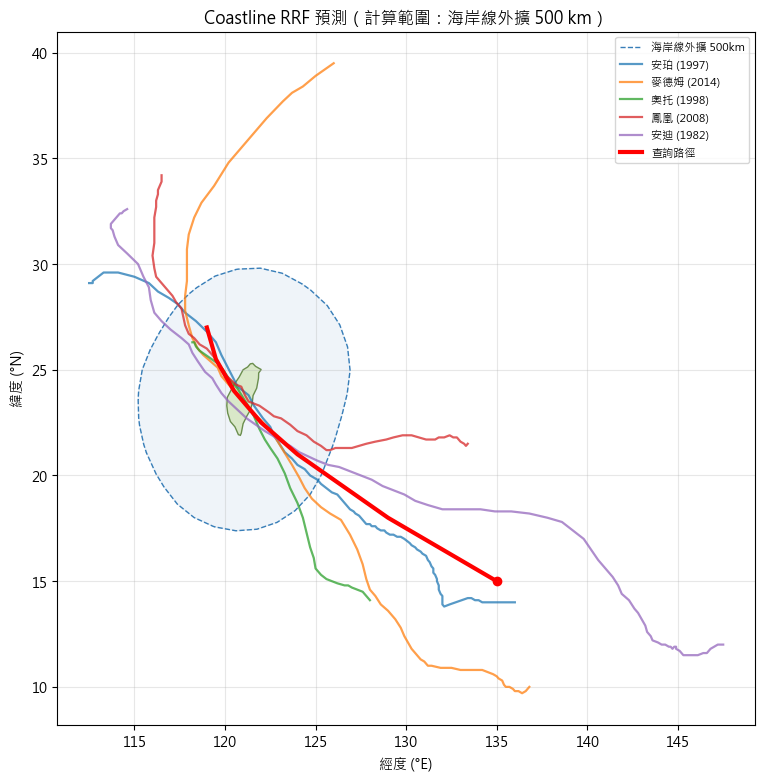

In [18]:
plt.rcParams['font.sans-serif'] = ['Microsoft JhengHei', 'Microsoft YaHei', 'SimHei', 'Noto Sans CJK TC']
plt.rcParams['axes.unicode_minus'] = False

outline = TAIWAN_OUTLINE_LONLAT + [TAIWAN_OUTLINE_LONLAT[0]]
buf = buffer_polygon(BUFFER_KM); buf = list(buf) + [buf[0]]
fig, ax = plt.subplots(figsize=(9, 9))
ax.fill([p[0] for p in buf], [p[1] for p in buf], color='#387eb8', alpha=0.08)
ax.plot([p[0] for p in buf], [p[1] for p in buf], '--', color='#387eb8', lw=1, label=f'海岸線外擴 {BUFFER_KM}km')
ax.fill([p[0] for p in outline], [p[1] for p in outline], color='#d9e8c8', ec='#6b8e4e')
for tid in res['ids']:
    r = model.rec_by_id[tid]
    ax.plot(r['track']['longitude'], r['track']['latitude'], lw=1.6, alpha=0.75, label=f"{r['name_zh']} ({r['year']})")
ax.plot(track_df['longitude'], track_df['latitude'], 'r-', lw=3, label='查詢路徑')
ax.plot(track_df['longitude'].iloc[0], track_df['latitude'].iloc[0], 'ro')
ax.set_xlabel('經度 (°E)'); ax.set_ylabel('緯度 (°N)')
ax.set_title(f'Coastline RRF 預測（計算範圍：海岸線外擴 {BUFFER_KM} km）')
ax.legend(fontsize=8, loc='upper right'); ax.grid(alpha=0.3)
plt.show()

## 10.（可選）整體評估 Leave-One-Out

對每筆颱風以其餘颱風為參考做留一驗證，回報目前 `BUFFER_KM` 下的準確率。


In [19]:
VALID = set('123456789')
correct = total = 0
for r in model.records:
    if r['category'] not in VALID: continue
    out = model.predict_track(r['track'], k=K,
                              q_rain=r['rain'].get(RAINFALL_REGION) if USE_RAINFALL else None,
                              exclude=r['id'])
    total += 1; correct += (out['predicted'] == r['category'])
print(f'Leave-One-Out 準確率：{correct/total*100:.1f}%  ({correct}/{total})')

Leave-One-Out 準確率：76.3%  (151/198)


## 11. 調整計算範圍重新預測

改變 `BUFFER_KM`，呼叫 `model.fit(新值)` 重新擬合後再預測。


In [20]:
NEW_BUFFER_KM = 300
model.fit(NEW_BUFFER_KM)
res2 = model.predict_track(track_df, k=K)
print(f'範圍 {NEW_BUFFER_KM}km → 預測類型 {res2["predicted"]}')
for tid in res2['ids']:
    r = model.rec_by_id[tid]
    off = path_offset_km(track_df['longitude'].values, track_df['latitude'].values,
                         r['track']['longitude'].values, r['track']['latitude'].values, NEW_BUFFER_KM)
    print(f"  {r['name_zh']}({r['year']}) cat{r['category']}  平均偏離 {off:.1f}km")
model.fit(BUFFER_KM)  # 還原

範圍 300km → 預測類型 3
  奧托(1998) cat3  平均偏離 40.8km
  麥德姆(2014) cat3  平均偏離 29.0km
  瓊安(1959) cat3  平均偏離 49.0km
  鳳凰(2008) cat3  平均偏離 50.8km
  安珀(1997) cat3  平均偏離 52.6km
